# Model Performance Comparison

`data/models/scratch/` 와 `data/models/embedding/` 에 저장된 TFLite 모델들을 비교한다.

섹션
1. 학습된 모델 인벤토리
2. 학습 곡선 (loss / 보조 metric)
3. 참조 데이터 로드
4. 검색 품질 지표 (top-k, MRR, tolerant acc, margin, per-dance)
5. 견고성 스위프 (corruption 강도별 성능 저하)
6. 효율성 (TFLite 크기, 파라미터 수, CPU 지연)
7. 통합 비교표 + 시각화 (Pareto, per-dance heatmap, scratch vs finetune)

In [1]:
import ctypes, glob as _glob, os, sys, json, time
from pathlib import Path
from collections import defaultdict

_nv = '/workspace/users/yijin/boot_env/.venv/lib/python3.12/site-packages/nvidia'
if os.path.isdir(_nv):
    for _so in sorted(_glob.glob(f'{_nv}/*/lib/*.so.*')):
        try: ctypes.CDLL(_so, mode=ctypes.RTLD_GLOBAL)
        except OSError: pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

start = Path.cwd().resolve()
PROJECT_ROOT = None
for base in [start, *start.parents]:
    if (base / 'data' / 'reference_dances').exists() and (base / 'src' / 'embedding').exists():
        PROJECT_ROOT = base
        break
if PROJECT_ROOT is None:
    raise RuntimeError('project root not found')
sys.path.insert(0, str(PROJECT_ROOT))

import tensorflow as tf

SCRATCH_DIR   = PROJECT_ROOT / 'data/models/scratch'
EMBED_DIR     = PROJECT_ROOT / 'data/models/embedding'
PRETRAIN_DIR  = PROJECT_ROOT / 'data/models/pretrain/mpose2021'
DATA_DIR      = PROJECT_ROOT / 'data/reference_dances'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('scratch  :', SCRATCH_DIR, '(exists)' if SCRATCH_DIR.exists() else '(missing)')
print('embedding:', EMBED_DIR,   '(exists)' if EMBED_DIR.exists() else '(missing)')
print('pretrain :', PRETRAIN_DIR,'(exists)' if PRETRAIN_DIR.exists() else '(missing)')
print('TF:', tf.__version__, '| GPU:', [d.name for d in tf.config.list_physical_devices('GPU')] or 'cpu only')

I0000 00:00:1776776768.444677 3442793 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


PROJECT_ROOT: /workspace/users/yijin/boot_env/pjt
scratch  : /workspace/users/yijin/boot_env/pjt/data/models/scratch (exists)
embedding: /workspace/users/yijin/boot_env/pjt/data/models/embedding (exists)
pretrain : /workspace/users/yijin/boot_env/pjt/data/models/pretrain/mpose2021 (exists)
TF: 2.21.0 | GPU: ['/physical_device:GPU:0']


## 1. 학습된 모델 인벤토리

각 `*_meta.json` 을 파싱해서 regime/arch/size/loss 로 분류.

In [2]:
def parse_meta(path):
    try:
        return json.loads(Path(path).read_text())
    except Exception as exc:
        print(f'[WARN] failed to parse {path}: {exc}')
        return None

def infer_size(embedding_dim):
    return {32: 'small', 64: 'base'}.get(int(embedding_dim or -1), 'other')

def scan_models(directory, regime):
    records = []
    if not directory.exists():
        return records
    for meta_path in sorted(directory.glob('*_meta.json')):
        meta = parse_meta(meta_path)
        if meta is None:
            continue
        base = meta_path.stem[:-len('_meta')]
        cfg = meta.get('config', {})
        tflite_path = directory / f'{base}.tflite'
        records.append({
            'regime': regime,
            'name': base,
            'model': cfg.get('model'),
            'loss': cfg.get('loss'),
            'embedding_dim': cfg.get('embedding_dim'),
            'size': infer_size(cfg.get('embedding_dim')),
            'pretrained': bool(cfg.get('pretrained_weights')),
            'tflite_path': tflite_path,
            'tflite_exists': tflite_path.exists(),
            'meta_path': meta_path,
            'meta': meta,
        })
    return records

inventory = scan_models(SCRATCH_DIR, 'scratch') + scan_models(EMBED_DIR, 'finetune')
pretrain_inventory = scan_models(PRETRAIN_DIR, 'pretrain')

inv_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('meta',)} for r in inventory])
print(f'scratch+finetune: {len(inventory)} | pretrain: {len(pretrain_inventory)}')
inv_df

scratch+finetune: 24 | pretrain: 6


,regime,name,model,loss,embedding_dim,size,pretrained,tflite_path,tflite_exists,meta_path
0,scratch,scratch_gcn_base_infonce_e64_final,gcn,infonce,64,base,False,/workspace/users/yijin/boot_env/pjt/data/model...,True,/workspace/users/yijin/boot_env/pjt/data/model...
1,scratch,scratch_gcn_base_triplet_e64_final,gcn,triplet,64,base,False,/workspace/users/yijin/boot_env/pjt/data/model...,True,/workspace/users/yijin/boot_env/pjt/data/model...
2,scratch,scratch_gcn_small_infonce_e32_final,gcn,infonce,32,small,False,/workspace/users/yijin/boot_env/pjt/data/model...,True,/workspace/users/yijin/boot_env/pjt/data/model...
3,scratch,scratch_gcn_small_triplet_e32_final,gcn,triplet,32,small,False,/workspace/users/yijin/boot_env/pjt/data/model...,True,/workspace/users/yijin/boot_env/pjt/data/model...
4,scratch,scratch_mlp_base_infonce_e64_final,mlp,infonce,64,base,False,/workspace/users/yijin/boot_env/pjt/data/model...,True,/workspace/users/yijin/boot_env/pjt/data/model...
5,scratch,scratch_mlp_base_triplet_e64_final,mlp,triplet,64,base,False,/workspace/users/yijin/boot_env/pjt/data/model...,True,/workspace/users/yijin/boot_env/pjt/data/model...
6,scratch,scratch_mlp_small_infonce_e32_final,mlp,infonce,32,small,False,/workspace/users/yijin/boot_env/pjt/data/model...,True,/workspace/users/yijin/boot_env/pjt/data/model...
7,scratch,scratch_mlp_small_triplet_e32_final,mlp,triplet,32,small,False,/workspace/users/yijin/boot_env/pjt/data/model...,True,/workspace/users/yijin/boot_env/pjt/data/model...
8,scratch,scratch_tcn_base_infonce_e64_final,tcn,infonce,64,base,False,/workspace/users/yijin/boot_env/pjt/data/model...,True,/workspace/users/yijin/boot_env/pjt/data/model...
9,scratch,scratch_tcn_base_triplet_e64_final,tcn,triplet,64,base,False,/workspace/users/yijin/boot_env/pjt/data/model...,True,/workspace/users/yijin/boot_env/pjt/data/model...


## 2. 학습 곡선

- 같은 `(model, size, loss)` 조합의 scratch/finetune 을 한 패널에 겹쳐 그린다.
- 왼쪽: loss / val_loss, 오른쪽: 보조 metric (infonce=retrieval_acc, triplet=pos_margin).
- 이어서 pretrain 단계 loss 도 참고용으로.

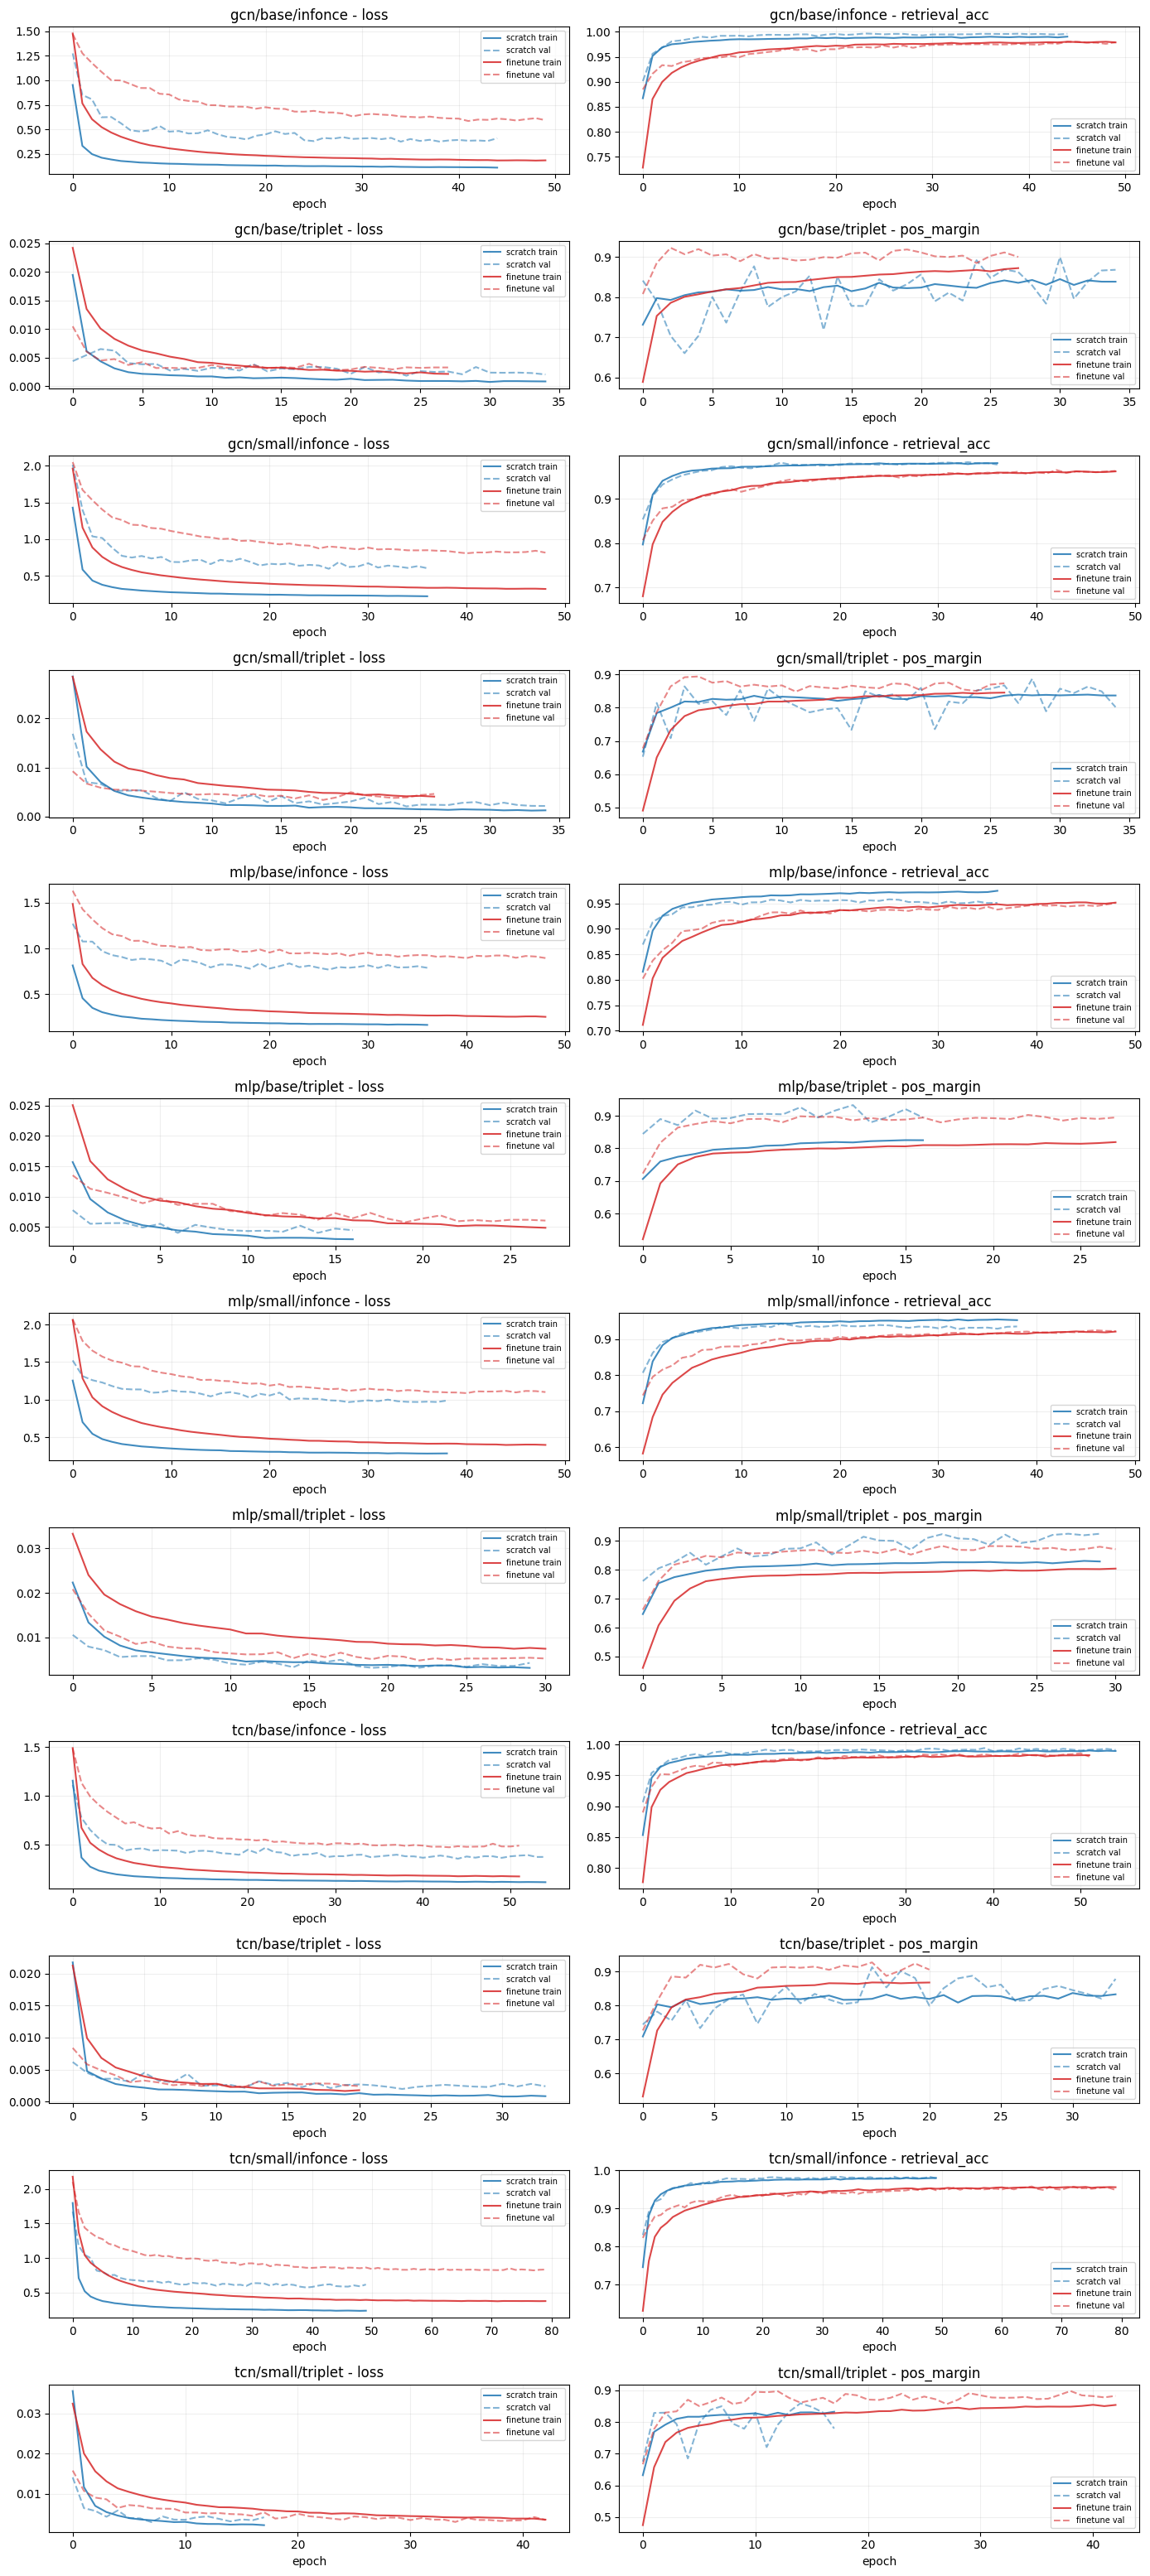

In [3]:
def plot_training_curves(records):
    grouped = defaultdict(dict)
    for r in records:
        key = (r['model'], r['size'], r['loss'])
        grouped[key][r['regime']] = r
    keys = sorted(grouped.keys(), key=lambda k: (k[0], k[1], k[2]))
    if not keys:
        print('no training histories found')
        return
    n = len(keys)
    fig, axes = plt.subplots(n, 2, figsize=(14, 2.6 * n))
    if n == 1:
        axes = axes[None, :]
    for ri, key in enumerate(keys):
        ax_l, ax_m = axes[ri, 0], axes[ri, 1]
        pair = grouped[key]
        metric = 'retrieval_acc' if key[2] == 'infonce' else 'pos_margin'
        for regime, r in pair.items():
            hist = r['meta'].get('history', {})
            color = 'C0' if regime == 'scratch' else 'C3'
            if hist.get('loss'):
                ax_l.plot(hist['loss'], color=color, linestyle='-', alpha=0.85, label=f'{regime} train')
            if hist.get('val_loss'):
                ax_l.plot(hist['val_loss'], color=color, linestyle='--', alpha=0.55, label=f'{regime} val')
            if hist.get(metric):
                ax_m.plot(hist[metric], color=color, linestyle='-', alpha=0.85, label=f'{regime} train')
            if hist.get(f'val_{metric}'):
                ax_m.plot(hist[f'val_{metric}'], color=color, linestyle='--', alpha=0.55, label=f'{regime} val')
        title = '/'.join(str(k) for k in key)
        ax_l.set_title(f'{title} - loss')
        ax_m.set_title(f'{title} - {metric}')
        for ax in (ax_l, ax_m):
            ax.set_xlabel('epoch')
            ax.grid(alpha=0.2)
            if ax.has_data():
                ax.legend(fontsize=7, loc='best')
    plt.tight_layout()
    plt.show()

plot_training_curves(inventory)

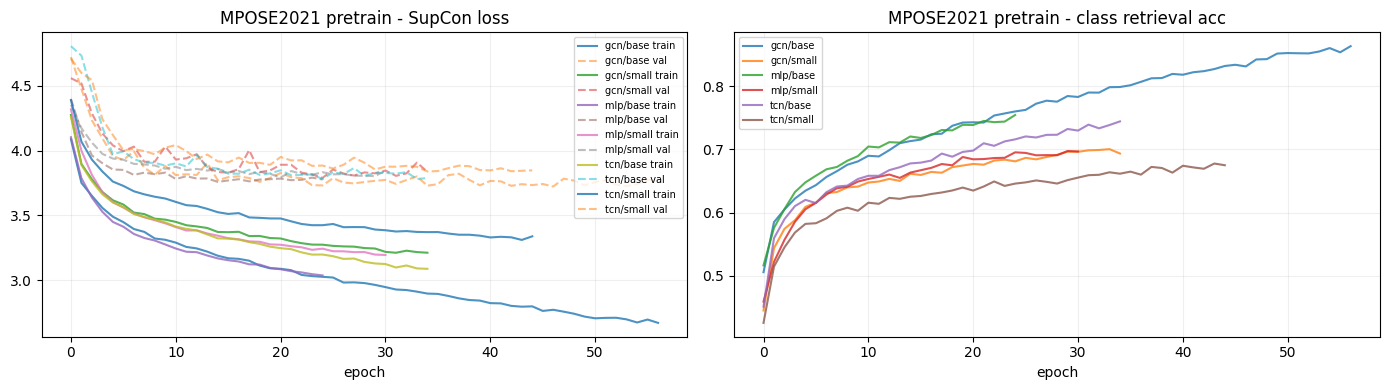

In [4]:
if pretrain_inventory:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for r in pretrain_inventory:
        hist = r['meta'].get('history', {})
        label = f"{r['model']}/{r['size']}"
        if hist.get('loss'):
            axes[0].plot(hist['loss'], label=f'{label} train', alpha=0.8)
        if hist.get('val_loss'):
            axes[0].plot(hist['val_loss'], linestyle='--', alpha=0.5, label=f'{label} val')
        if hist.get('class_retrieval_acc'):
            axes[1].plot(hist['class_retrieval_acc'], label=label, alpha=0.8)
    axes[0].set_title('MPOSE2021 pretrain - SupCon loss'); axes[0].set_xlabel('epoch'); axes[0].legend(fontsize=7)
    axes[1].set_title('MPOSE2021 pretrain - class retrieval acc'); axes[1].set_xlabel('epoch'); axes[1].legend(fontsize=7)
    for ax in axes: ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()
else:
    print('no pretrain runs found')

## 3. 참조 데이터 로드

`ContrastiveSequenceStore` 는 `reference.npy` + augment 들을 12-joint + hip/torso 정규화된 상태로 로드한다. 모든 평가에서 이 store 를 공유한다.

In [4]:
from src.embedding.dataset_contrastive import (
    ContrastiveSequenceStore, sample_candidate_indices,
    apply_runtime_window_augment, TARGET_DANCES,
)

SEQUENCE_LENGTH = 30
FEATURE_DIMS = 2
NUM_JOINTS = 12

store = ContrastiveSequenceStore(
    DATA_DIR, dances=TARGET_DANCES, feature_dims=FEATURE_DIMS, verbose=False)
print(f'{len(store)} dances:')
for b in store.bundles:
    print(f'  {b.name:20s} T={b.num_frames:5d} augments={len(b.augments)}')

8 dances:
  404_dance            T=  568 augments=30
  basic_movement       T=  476 augments=30
  beginner_wave        T=  679 augments=30
  cheerup_dance        T=  724 augments=30
  hiphop_move          T=  792 augments=30
  kpop_basic           T= 7164 augments=30
  rasputin             T= 3147 augments=30
  shuffle_dance        T= 1538 augments=30


## 4. 검색 품질 지표 (clean)

학습 파이프라인의 `runtime_alignment_metrics` 를 확장해서:
- `top1/3/5`, `MRR`, `rank_p90` (분포 꼬리)
- `tolerant_acc @ {3,6,12}` (서비스 실질 KPI — 몇 프레임 이내에 맞춰야 정답으로 봄)
- `margin_mean/median/p10` (정답 vs 최선의 오답 cos 차이)
- `per_dance_top1` / `worst_dance_top1` (곡별 편차)

In [5]:
def _resolve_interpreter_cls():
    try:
        from ai_edge_litert.interpreter import Interpreter
        return Interpreter
    except ImportError:
        return tf.lite.Interpreter

_InterpreterCls = _resolve_interpreter_cls()


class TFLiteEncoder:
    """TFLite wrapper that runs the model at its native batch=1 shape.

    TFLite was exported with input_signature=[1, T, J, C] so the XNNPACK
    delegate compiles for batch=1. Calling resize_tensor_input to widen the
    batch causes `XNNPack delegate failed to reshape` on some graphs
    (TCN/GCN with dilated Conv2D). Mirror the service loop: batch=1 per
    invoke, loop inside.
    """

    def __init__(self, tflite_path, T=30, J=12, C=2):
        self.path = str(tflite_path)
        self.T, self.J, self.C = T, J, C
        self.interp = _InterpreterCls(model_path=self.path)
        det_in = self.interp.get_input_details()[0]
        shape_sig = det_in.get('shape_signature', det_in.get('shape'))
        if shape_sig is not None and np.any(np.array(shape_sig) < 0):
            self.interp.resize_tensor_input(det_in['index'], [1, T, J, C], strict=False)
        self.interp.allocate_tensors()
        self._in = self.interp.get_input_details()[0]
        self._out = self.interp.get_output_details()[0]

    def _invoke_one(self, window):
        x = np.ascontiguousarray(window[None, ...].astype(self._in['dtype']))
        self.interp.set_tensor(self._in['index'], x)
        self.interp.invoke()
        return np.asarray(self.interp.get_tensor(self._out['index']), dtype=np.float32).reshape(-1)

    def __call__(self, x):
        x = np.asarray(x, dtype=np.float32)
        if x.ndim == 3:
            x = x[None, ...]
        embs = np.stack([self._invoke_one(w) for w in x], axis=0)
        norms = np.linalg.norm(embs, axis=1, keepdims=True)
        return embs / np.maximum(norms, 1e-8)


def enhanced_retrieval_metrics(encoder_fn, store, sequence_length=30,
                               tolerance=12, stride=3, max_samples=256,
                               seed=42, corruption=None, aug_prob=0.7):
    rng = np.random.default_rng(seed)
    corruption = corruption or {}
    records = []
    for _ in range(max_samples):
        bi = int(rng.integers(len(store)))
        bundle = store.bundles[bi]
        if bundle.num_frames <= sequence_length:
            continue
        end = int(rng.integers(sequence_length - 1, bundle.num_frames))
        base = bundle.original[end - sequence_length + 1:end + 1]
        if bundle.augments and rng.random() < aug_prob:
            aug = bundle.augments[int(rng.integers(len(bundle.augments)))]
            base = aug[end - sequence_length + 1:end + 1]
        user = apply_runtime_window_augment(base, rng, **corruption)
        cands = sample_candidate_indices(
            bundle.num_frames, end, tolerance_frames=tolerance,
            stride=stride, min_end_index=sequence_length - 1)
        if end not in cands:
            continue
        cand_windows = np.stack([
            bundle.original[i - sequence_length + 1:i + 1] for i in cands
        ]).astype(np.float32)
        stacked = np.concatenate([user[None, ...], cand_windows], axis=0).astype(np.float32)
        embs = encoder_fn(stacked)
        u_emb = embs[0]
        r_embs = embs[1:]
        sims = r_embs @ u_emb
        order = np.argsort(-sims)
        ordered_ends = [cands[int(i)] for i in order]
        tgt_rank = ordered_ends.index(end) + 1
        tgt_idx = cands.index(end)
        tgt_sim = float(sims[tgt_idx])
        mask = np.ones(len(cands), dtype=bool)
        mask[tgt_idx] = False
        best_wrong = float(sims[mask].max()) if mask.any() else tgt_sim
        pred_end = ordered_ends[0]
        records.append({
            'dance': store.names[bi],
            'target_rank': tgt_rank,
            'target_sim': tgt_sim,
            'best_wrong': best_wrong,
            'margin': tgt_sim - best_wrong,
            'frame_err': abs(pred_end - end),
        })
    df = pd.DataFrame(records)
    if df.empty:
        return {'n': 0}
    per_dance_top1 = df.groupby('dance').apply(lambda g: float((g['target_rank'] == 1).mean()))
    return {
        'n': len(df),
        'top1': float((df['target_rank'] == 1).mean()),
        'top3': float((df['target_rank'] <= 3).mean()),
        'top5': float((df['target_rank'] <= 5).mean()),
        'mrr': float((1.0 / df['target_rank']).mean()),
        'rank_mean': float(df['target_rank'].mean()),
        'rank_p90': float(df['target_rank'].quantile(0.9)),
        'target_sim_mean': float(df['target_sim'].mean()),
        'margin_mean': float(df['margin'].mean()),
        'margin_median': float(df['margin'].median()),
        'margin_p10': float(df['margin'].quantile(0.1)),
        'tolerant_acc_3': float((df['frame_err'] <= 3).mean()),
        'tolerant_acc_6': float((df['frame_err'] <= 6).mean()),
        'tolerant_acc_12': float((df['frame_err'] <= 12).mean()),
        'worst_dance_top1': float(per_dance_top1.min()),
        'per_dance_top1_std': float(per_dance_top1.std()),
        'per_dance_top1': {k: float(v) for k, v in per_dance_top1.to_dict().items()},
    }

In [6]:
CLEAN_SAMPLES = 256
clean_results = {}
for r in inventory:
    if not r['tflite_exists']:
        print(f'[skip] {r["name"]}: no tflite')
        continue
    t0 = time.perf_counter()
    enc = TFLiteEncoder(r['tflite_path'], T=SEQUENCE_LENGTH, J=NUM_JOINTS, C=FEATURE_DIMS)
    metrics = enhanced_retrieval_metrics(
        enc, store, sequence_length=SEQUENCE_LENGTH,
        max_samples=CLEAN_SAMPLES, seed=42)
    key = (r['regime'], r['model'], r['size'], r['loss'])
    clean_results[key] = metrics
    dt = time.perf_counter() - t0
    print(f'[{dt:5.1f}s] {r["regime"]:<8s} {r["name"]:<45s} '
          f'top1={metrics["top1"]:.3f} tol6={metrics["tolerant_acc_6"]:.3f} '
          f'margin_p10={metrics["margin_p10"]:+.3f} worst={metrics["worst_dance_top1"]:.3f}')

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


[  2.6s] scratch  scratch_gcn_base_infonce_e64_final            top1=0.988 tol6=0.992 margin_p10=+0.046 worst=0.949
[  2.6s] scratch  scratch_gcn_base_triplet_e64_final            top1=0.973 tol6=0.992 margin_p10=+0.030 worst=0.933
[  0.7s] scratch  scratch_gcn_small_infonce_e32_final           top1=0.980 tol6=0.992 margin_p10=+0.021 worst=0.920
[  0.7s] scratch  scratch_gcn_small_triplet_e32_final           top1=0.969 tol6=0.988 margin_p10=+0.024 worst=0.923
[  0.1s] scratch  scratch_mlp_base_infonce_e64_final            top1=0.961 tol6=0.984 margin_p10=+0.008 worst=0.846
[  0.1s] scratch  scratch_mlp_base_triplet_e64_final            top1=0.910 tol6=0.984 margin_p10=+0.001 worst=0.760
[  0.1s] scratch  scratch_mlp_small_infonce_e32_final           top1=0.945 tol6=0.984 margin_p10=+0.003 worst=0.821
[  0.1s] scratch  scratch_mlp_small_triplet_e32_final           top1=0.922 tol6=0.984 margin_p10=+0.002 worst=0.821
[  1.4s] scratch  scratch_tcn_base_infonce_e64_final            top1=0.9

In [7]:
clean_rows = []
for r in inventory:
    key = (r['regime'], r['model'], r['size'], r['loss'])
    m = clean_results.get(key)
    if m is None:
        continue
    clean_rows.append({
        'regime': r['regime'], 'model': r['model'], 'size': r['size'], 'loss': r['loss'],
        'top1': m['top1'], 'top3': m['top3'], 'top5': m['top5'],
        'mrr': m['mrr'], 'rank_p90': m['rank_p90'],
        'tol3': m['tolerant_acc_3'], 'tol6': m['tolerant_acc_6'], 'tol12': m['tolerant_acc_12'],
        'margin_mean': m['margin_mean'], 'margin_p10': m['margin_p10'],
        'worst_dance': m['worst_dance_top1'], 'per_dance_std': m['per_dance_top1_std'],
    })
clean_df = pd.DataFrame(clean_rows).sort_values(['model', 'size', 'loss', 'regime']).reset_index(drop=True)
clean_df

,regime,model,size,loss,top1,top3,top5,mrr,rank_p90,tol3,tol6,tol12,margin_mean,margin_p10,worst_dance,per_dance_std
0,finetune,gcn,base,infonce,0.980469,0.992188,1.000000,0.986589,1.0,0.988281,0.992188,1.0,0.062515,0.023925,0.923077,0.028305
1,scratch,gcn,base,infonce,0.988281,0.992188,1.000000,0.991797,1.0,0.992188,0.992188,1.0,0.101585,0.045901,0.948718,0.018868
2,finetune,gcn,base,triplet,0.937500,0.984375,1.000000,0.962305,1.0,0.980469,0.984375,1.0,0.054440,0.008041,0.871795,0.037600
3,scratch,gcn,base,triplet,0.972656,0.992188,1.000000,0.983333,1.0,0.992188,0.992188,1.0,0.090953,0.030270,0.933333,0.025896
4,finetune,gcn,small,infonce,0.949219,0.984375,0.996094,0.968592,1.0,0.980469,0.984375,1.0,0.042245,0.008612,0.880000,0.041326
5,scratch,gcn,small,infonce,0.980469,0.992188,1.000000,0.987240,1.0,0.992188,0.992188,1.0,0.062894,0.021211,0.920000,0.031538
6,finetune,gcn,small,triplet,0.933594,0.984375,0.996094,0.961886,1.0,0.984375,0.984375,1.0,0.037655,0.004964,0.880000,0.047242
7,scratch,gcn,small,triplet,0.968750,0.992188,1.000000,0.982031,1.0,0.988281,0.988281,1.0,0.077650,0.024245,0.923077,0.030205
8,finetune,mlp,base,infonce,0.941406,0.988281,1.000000,0.965885,1.0,0.980469,0.988281,1.0,0.043061,0.004274,0.871795,0.039579
9,scratch,mlp,base,infonce,0.960938,0.984375,1.000000,0.975521,1.0,0.976562,0.984375,1.0,0.058625,0.007971,0.846154,0.050656


## 5. 견고성 스위프 (corruption levels)

`apply_runtime_window_augment` 의 강도를 단계별로 올리면서 top1 저하 곡선을 본다.  
`robust_auc` = 네 단계 평균 top1 (하나의 스칼라로 견고성 비교용).

In [8]:
CORRUPTIONS = [
    ('none',     {}),
    ('light',    dict(gaussian_sigma=0.005, joint_dropout_prob=0.04, frame_hold_prob=0.05,
                      temporal_warp_prob=0.25, temporal_warp_strength=0.15)),
    ('moderate', dict(gaussian_sigma=0.015, joint_dropout_prob=0.10, frame_hold_prob=0.10,
                      temporal_warp_prob=0.50, temporal_warp_strength=0.25)),
    ('heavy',    dict(gaussian_sigma=0.030, joint_dropout_prob=0.20, frame_hold_prob=0.20,
                      temporal_warp_prob=0.80, temporal_warp_strength=0.35)),
]
ROBUST_SAMPLES = 128

robust_results = {}
for r in inventory:
    if not r['tflite_exists']:
        continue
    enc = TFLiteEncoder(r['tflite_path'], T=SEQUENCE_LENGTH, J=NUM_JOINTS, C=FEATURE_DIMS)
    key = (r['regime'], r['model'], r['size'], r['loss'])
    row = {}
    for cname, crp in CORRUPTIONS:
        m = enhanced_retrieval_metrics(
            enc, store, sequence_length=SEQUENCE_LENGTH,
            max_samples=ROBUST_SAMPLES, seed=1000 + hash(cname) % 1000,
            corruption=crp)
        row[cname] = m.get('top1', float('nan'))
    row['robust_auc'] = float(np.nanmean(list(row.values())))
    robust_results[key] = row
    print(f'{r["regime"]:<8s} {r["name"]:<45s} '
          + '  '.join(f'{c}={row[c]:.3f}' for c, _ in CORRUPTIONS)
          + f'  AUC={row["robust_auc"]:.3f}')

scratch  scratch_gcn_base_infonce_e64_final            none=0.992  light=0.992  moderate=0.875  heavy=0.617  AUC=0.869
scratch  scratch_gcn_base_triplet_e64_final            none=0.984  light=0.969  moderate=0.883  heavy=0.609  AUC=0.861
scratch  scratch_gcn_small_infonce_e32_final           none=0.992  light=0.969  moderate=0.844  heavy=0.602  AUC=0.852
scratch  scratch_gcn_small_triplet_e32_final           none=0.977  light=0.961  moderate=0.805  heavy=0.602  AUC=0.836
scratch  scratch_mlp_base_infonce_e64_final            none=0.984  light=0.938  moderate=0.781  heavy=0.516  AUC=0.805
scratch  scratch_mlp_base_triplet_e64_final            none=0.984  light=0.867  moderate=0.656  heavy=0.398  AUC=0.727
scratch  scratch_mlp_small_infonce_e32_final           none=0.969  light=0.898  moderate=0.789  heavy=0.500  AUC=0.789
scratch  scratch_mlp_small_triplet_e32_final           none=0.961  light=0.836  moderate=0.688  heavy=0.453  AUC=0.734
scratch  scratch_tcn_base_infonce_e64_final     

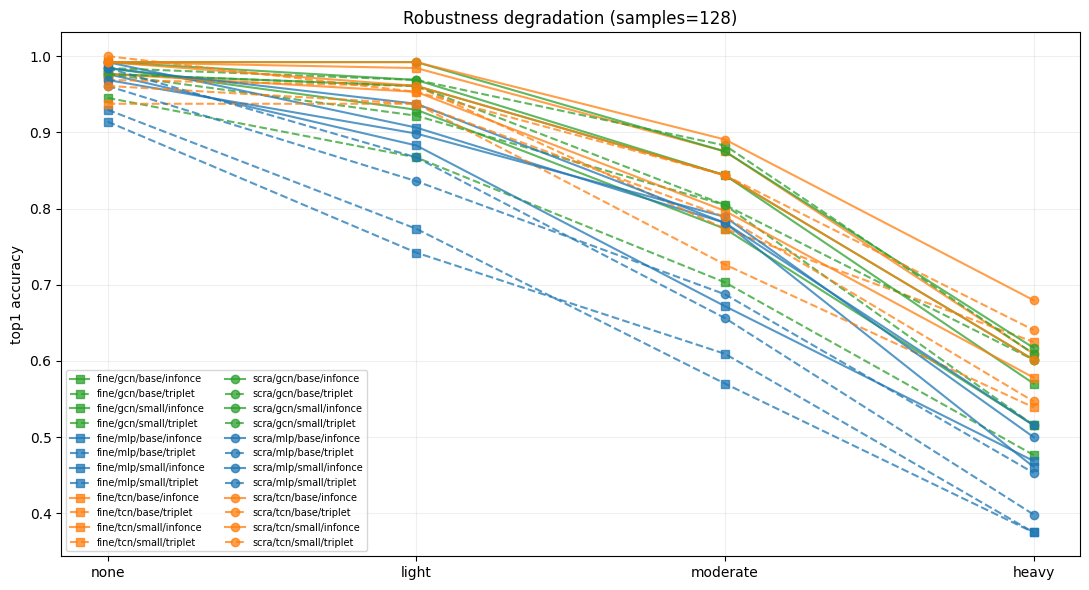

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
x_labels = [c for c, _ in CORRUPTIONS]
x = np.arange(len(x_labels))
style_by_loss = {'infonce': '-', 'triplet': '--'}
color_by_model = {'mlp': 'C0', 'tcn': 'C1', 'gcn': 'C2'}
marker_by_regime = {'scratch': 'o', 'finetune': 's'}

for (regime, model, size, loss), row in sorted(robust_results.items()):
    ys = [row[c] for c in x_labels]
    ax.plot(x, ys,
            color=color_by_model.get(model, 'gray'),
            linestyle=style_by_loss.get(loss, '-'),
            marker=marker_by_regime.get(regime, 'x'),
            alpha=0.75,
            label=f'{regime[:4]}/{model}/{size}/{loss}')
ax.set_xticks(x); ax.set_xticklabels(x_labels)
ax.set_ylabel('top1 accuracy')
ax.set_title(f'Robustness degradation (samples={ROBUST_SAMPLES})')
ax.grid(alpha=0.2)
ax.legend(fontsize=7, ncol=2, loc='lower left')
plt.tight_layout(); plt.show()

## 6. 효율성 (TFLite 크기, 파라미터 수, CPU 지연)

- `tflite_size_kib`: 파일 크기
- `param_count`: meta 의 config 로 encoder 재조립 후 `count_params()`
- `latency_p50_ms`, `latency_p95_ms`: batch=1 TFLite invoke 를 50회 측정 (warmup 5회). 30fps 예산은 33ms.

In [10]:
from src.embedding.models_scratch import build_encoder

def _encoder_kwargs(cfg):
    m = cfg.get('model')
    kw = {'dropout': cfg.get('dropout', 0.15)}
    if m == 'mlp':
        kw['hidden'] = cfg.get('mlp_hidden', 128)
    elif m == 'tcn':
        kw.update(filters=cfg.get('tcn_filters', 64), blocks=cfg.get('tcn_blocks', 4),
                  kernel_size=cfg.get('tcn_kernel', 3))
    else:
        kw.update(filters=cfg.get('gcn_filters', 64), blocks=cfg.get('gcn_blocks', 3),
                  kernel_size=cfg.get('gcn_kernel', 9),
                  partition_strategy=cfg.get('gcn_partition', 'distance'))
    return kw

def count_params_from_meta(meta):
    cfg = meta.get('config', {})
    enc = build_encoder(
        cfg.get('model'),
        sequence_length=cfg.get('sequence_length', SEQUENCE_LENGTH),
        num_joints=NUM_JOINTS,
        feature_dims=cfg.get('feature_dims', FEATURE_DIMS),
        embedding_dim=cfg.get('embedding_dim', 64),
        **_encoder_kwargs(cfg))
    return int(enc.count_params())

def measure_latency(tflite_path, T=30, J=12, C=2, warmup=5, runs=50):
    interp = tf.lite.Interpreter(model_path=str(tflite_path))
    det_in = interp.get_input_details()[0]
    interp.resize_tensor_input(det_in['index'], [1, T, J, C], strict=False)
    interp.allocate_tensors()
    det_in = interp.get_input_details()[0]
    x = np.zeros([1, T, J, C], dtype=det_in['dtype'])
    for _ in range(warmup):
        interp.set_tensor(det_in['index'], x); interp.invoke()
    times_ms = np.empty(runs, dtype=np.float64)
    for i in range(runs):
        t0 = time.perf_counter()
        interp.set_tensor(det_in['index'], x); interp.invoke()
        times_ms[i] = (time.perf_counter() - t0) * 1000.0
    return {
        'latency_p50_ms': float(np.percentile(times_ms, 50)),
        'latency_p95_ms': float(np.percentile(times_ms, 95)),
    }

efficiency = {}
for r in inventory:
    if not r['tflite_exists']:
        continue
    key = (r['regime'], r['model'], r['size'], r['loss'])
    eff = {
        'tflite_size_kib': os.path.getsize(r['tflite_path']) / 1024.0,
        'param_count': count_params_from_meta(r['meta']),
    }
    eff.update(measure_latency(r['tflite_path'],
                                T=SEQUENCE_LENGTH, J=NUM_JOINTS, C=FEATURE_DIMS))
    efficiency[key] = eff
    print(f'{r["regime"]:<8s} {r["name"]:<45s} '
          f'size={eff["tflite_size_kib"]:7.1f}KiB  '
          f'params={eff["param_count"]:>8d}  '
          f'p50={eff["latency_p50_ms"]:5.2f}ms  p95={eff["latency_p95_ms"]:5.2f}ms')

I0000 00:00:1776776941.267190 3442793 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1147 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:0a:00.0, compute capability: 8.6
/workspace/users/yijin/boot_env/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


scratch  scratch_gcn_base_infonce_e64_final            size=  188.4KiB  params=  158528  p50= 0.99ms  p95= 0.99ms
scratch  scratch_gcn_base_triplet_e64_final            size=  188.4KiB  params=  158528  p50= 1.00ms  p95= 1.01ms
scratch  scratch_gcn_small_infonce_e32_final           size=   47.7KiB  params=   27680  p50= 0.25ms  p95= 0.27ms
scratch  scratch_gcn_small_triplet_e32_final           size=   47.7KiB  params=   27680  p50= 0.27ms  p95= 0.27ms
scratch  scratch_mlp_base_infonce_e64_final            size=   40.5KiB  params=   33152  p50= 0.01ms  p95= 0.01ms
scratch  scratch_mlp_base_triplet_e64_final            size=   40.5KiB  params=   33152  p50= 0.01ms  p95= 0.02ms
scratch  scratch_mlp_small_infonce_e32_final           size=   15.0KiB  params=    9408  p50= 0.01ms  p95= 0.01ms
scratch  scratch_mlp_small_triplet_e32_final           size=   15.0KiB  params=    9408  p50= 0.01ms  p95= 0.01ms
scratch  scratch_tcn_base_infonce_e64_final            size=  126.7KiB  params=  109632 

## 7. 통합 비교표 + 시각화

- master DataFrame: 학습 요약 + clean + robust + efficiency
- Pareto 산점도: 지연 vs tolerant_acc_6
- Per-dance heatmap: 어떤 모델이 어떤 곡에서 약한지
- scratch vs finetune delta: pretrain+finetune 이 scratch 를 얼마나 밀어올렸는가

In [11]:
rows = []
for r in inventory:
    key = (r['regime'], r['model'], r['size'], r['loss'])
    clean = clean_results.get(key, {})
    robust = robust_results.get(key, {})
    eff = efficiency.get(key, {})
    training = r['meta'].get('training_summary', {})
    rows.append({
        'regime': r['regime'], 'model': r['model'], 'size': r['size'], 'loss': r['loss'],
        'pretrained': r['pretrained'],
        'epochs': training.get('epochs_ran'),
        'best_val_loss': training.get('best_val_loss'),
        'best_epoch': training.get('best_epoch'),
        'top1': clean.get('top1'),
        'tol6': clean.get('tolerant_acc_6'),
        'margin_mean': clean.get('margin_mean'),
        'margin_p10': clean.get('margin_p10'),
        'worst_dance': clean.get('worst_dance_top1'),
        'robust_auc': robust.get('robust_auc'),
        'top1_heavy': robust.get('heavy'),
        'params': eff.get('param_count'),
        'tflite_kib': eff.get('tflite_size_kib'),
        'lat_p50_ms': eff.get('latency_p50_ms'),
        'lat_p95_ms': eff.get('latency_p95_ms'),
    })
master = pd.DataFrame(rows).sort_values(['model', 'size', 'loss', 'regime']).reset_index(drop=True)
master

,regime,model,size,loss,pretrained,epochs,best_val_loss,best_epoch,top1,tol6,margin_mean,margin_p10,worst_dance,robust_auc,top1_heavy,params,tflite_kib,lat_p50_ms,lat_p95_ms
0,finetune,gcn,base,infonce,True,50,0.585956,42,0.980469,0.992188,0.062515,0.023925,0.923077,0.837891,0.570312,158528,188.375000,1.011535,1.031457
1,scratch,gcn,base,infonce,False,45,0.376155,35,0.988281,0.992188,0.101585,0.045901,0.948718,0.869141,0.617188,158528,188.375000,0.986304,0.993199
2,finetune,gcn,base,triplet,True,28,0.002775,20,0.937500,0.984375,0.054440,0.008041,0.871795,0.804688,0.515625,158528,188.375000,0.990011,0.996628
3,scratch,gcn,base,triplet,False,35,0.001812,25,0.972656,0.992188,0.090953,0.030270,0.933333,0.861328,0.609375,158528,188.375000,1.003651,1.005744
4,finetune,gcn,small,infonce,True,49,0.807470,41,0.949219,0.984375,0.042245,0.008612,0.880000,0.800781,0.515625,27680,47.687500,0.252178,0.259116
5,scratch,gcn,small,infonce,False,37,0.596442,27,0.980469,0.992188,0.062894,0.021211,0.920000,0.851562,0.601562,27680,47.687500,0.253500,0.272003
6,finetune,gcn,small,triplet,True,27,0.003366,19,0.933594,0.984375,0.037655,0.004964,0.880000,0.748047,0.476562,27680,47.687500,0.251932,0.258407
7,scratch,gcn,small,triplet,False,35,0.002059,25,0.968750,0.988281,0.077650,0.024245,0.923077,0.835938,0.601562,27680,47.687500,0.267236,0.273986
8,finetune,mlp,base,infonce,True,49,0.895537,41,0.941406,0.988281,0.043061,0.004274,0.871795,0.785156,0.460938,33152,40.539062,0.012824,0.015543
9,scratch,mlp,base,infonce,False,37,0.769437,27,0.960938,0.984375,0.058625,0.007971,0.846154,0.804688,0.515625,33152,40.539062,0.012754,0.012897


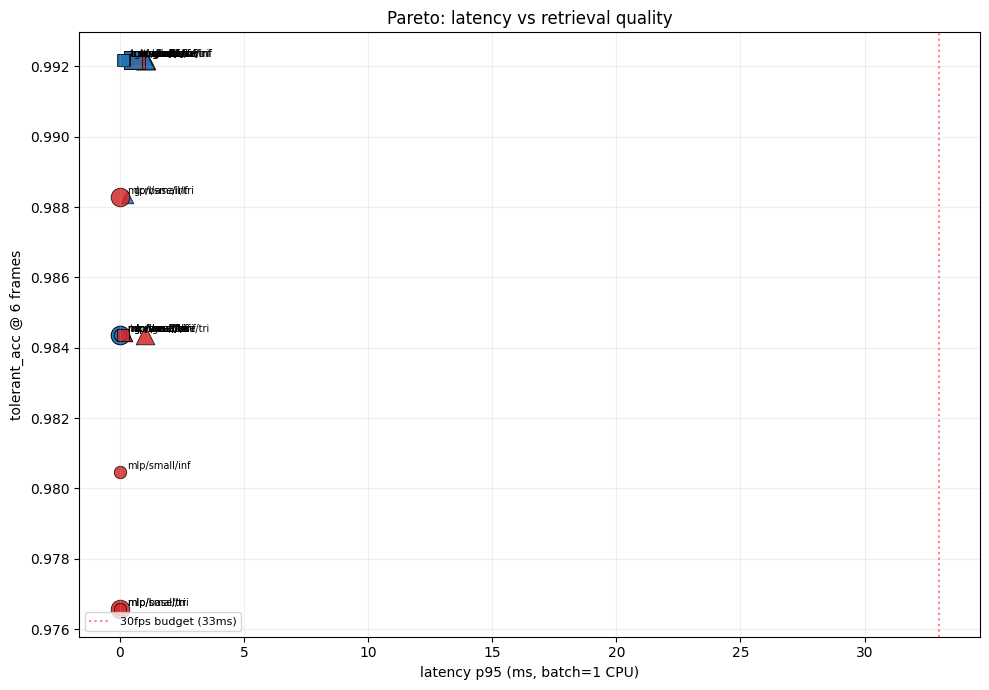

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))
palette = {'scratch': 'C0', 'finetune': 'C3'}
marker_by_arch = {'mlp': 'o', 'tcn': 's', 'gcn': '^'}
for _, row in master.iterrows():
    if pd.isna(row['lat_p95_ms']) or pd.isna(row['tol6']):
        continue
    size_scale = 80 if row['size'] == 'small' else 180
    ax.scatter(row['lat_p95_ms'], row['tol6'],
               s=size_scale, c=palette.get(row['regime'], 'gray'),
               marker=marker_by_arch.get(row['model'], 'x'),
               edgecolor='black', linewidths=0.6, alpha=0.85)
    ax.annotate(f"{row['model']}/{row['size']}/{row['loss'][:3]}",
                (row['lat_p95_ms'], row['tol6']),
                fontsize=7, xytext=(5, 2), textcoords='offset points')
ax.axvline(33.0, color='red', linestyle=':', alpha=0.5, label='30fps budget (33ms)')
ax.set_xlabel('latency p95 (ms, batch=1 CPU)')
ax.set_ylabel('tolerant_acc @ 6 frames')
ax.set_title('Pareto: latency vs retrieval quality')
ax.grid(alpha=0.2); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

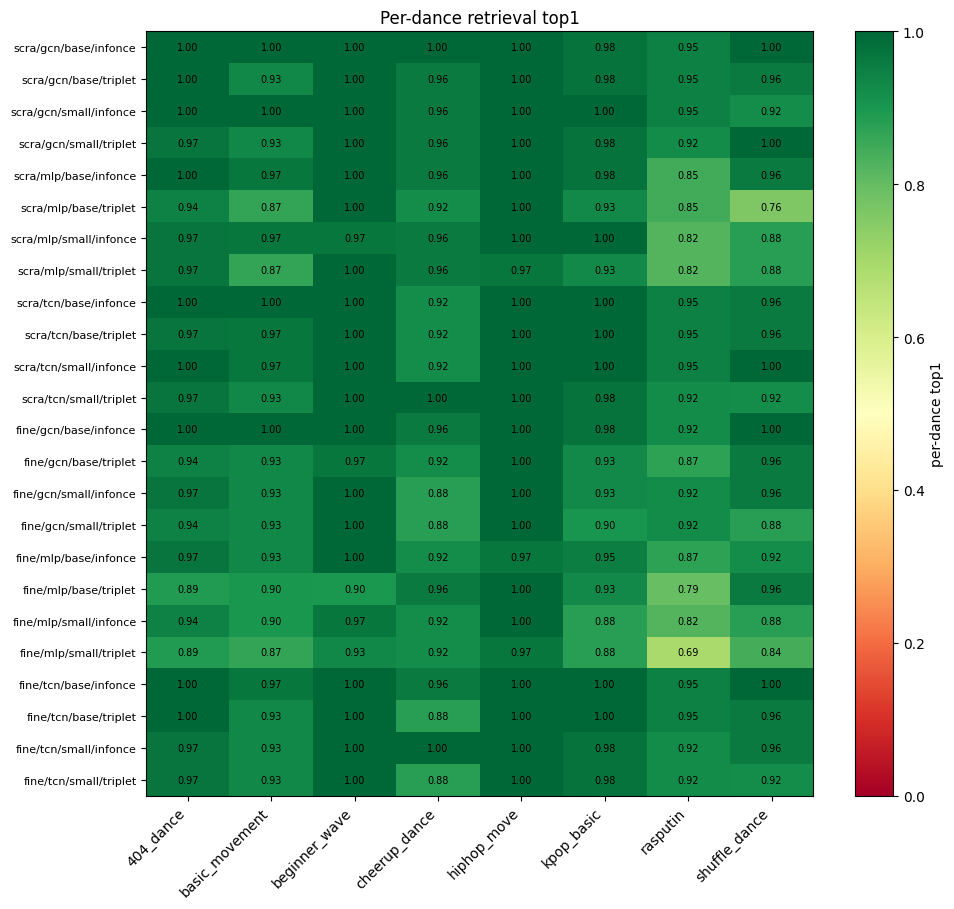

In [13]:
heat_rows, labels = [], []
for r in inventory:
    key = (r['regime'], r['model'], r['size'], r['loss'])
    m = clean_results.get(key)
    if m is None or 'per_dance_top1' not in m:
        continue
    heat_rows.append(m['per_dance_top1'])
    labels.append(f"{r['regime'][:4]}/{r['model']}/{r['size']}/{r['loss']}")

if heat_rows:
    heat_df = pd.DataFrame(heat_rows, index=labels).fillna(np.nan)
    heat_df = heat_df[sorted(heat_df.columns)]
    fig, ax = plt.subplots(figsize=(1.0 * len(heat_df.columns) + 2, 0.3 * len(heat_df) + 2))
    im = ax.imshow(heat_df.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(len(heat_df.columns)))
    ax.set_xticklabels(heat_df.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(heat_df.index)))
    ax.set_yticklabels(heat_df.index, fontsize=8)
    for i in range(heat_df.shape[0]):
        for j in range(heat_df.shape[1]):
            v = heat_df.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                        color='black' if v > 0.5 else 'white')
    fig.colorbar(im, ax=ax, label='per-dance top1')
    ax.set_title('Per-dance retrieval top1')
    plt.tight_layout(); plt.show()
else:
    print('no per-dance data')

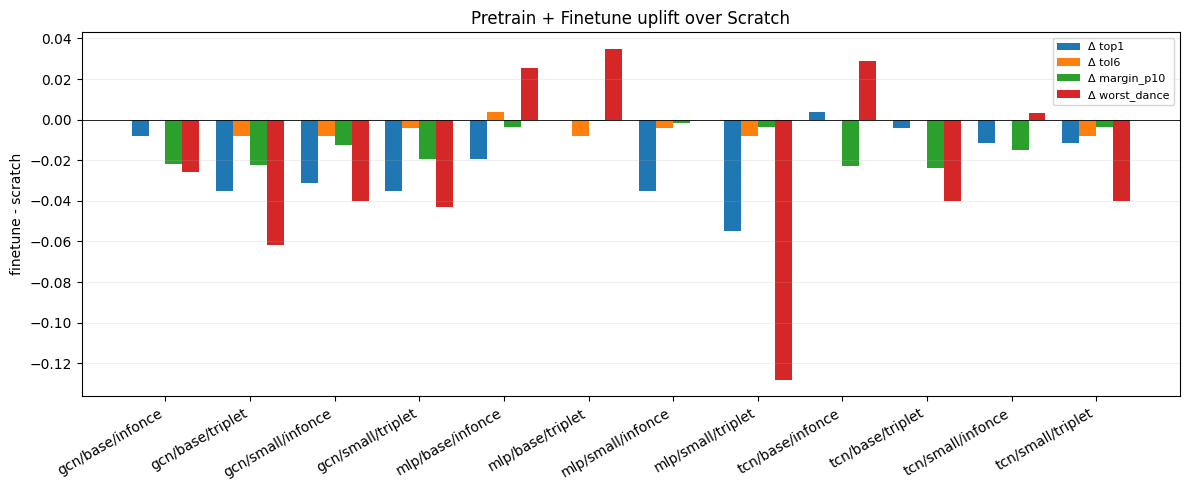

,d_top1,d_tol6,d_margin_p10,d_worst_dance
variant,,,,
gcn/base/infonce,-0.007812,0.000000,-0.021976,-0.025641
gcn/base/triplet,-0.035156,-0.007812,-0.022229,-0.061538
gcn/small/infonce,-0.031250,-0.007812,-0.012599,-0.040000
gcn/small/triplet,-0.035156,-0.003906,-0.019281,-0.043077
mlp/base/infonce,-0.019531,0.003906,-0.003697,0.025641
mlp/base/triplet,0.000000,-0.007812,-0.000666,0.034872
mlp/small/infonce,-0.035156,-0.003906,-0.001654,0.000000
mlp/small/triplet,-0.054688,-0.007812,-0.003798,-0.128205
tcn/base/infonce,0.003906,0.000000,-0.022877,0.028718


In [14]:
pair_keys = set()
for r in inventory:
    pair_keys.add((r['model'], r['size'], r['loss']))

deltas = []
for mk in sorted(pair_keys):
    model, size, loss = mk
    s = clean_results.get(('scratch', model, size, loss))
    f = clean_results.get(('finetune', model, size, loss))
    if s is None or f is None:
        continue
    deltas.append({
        'variant': f'{model}/{size}/{loss}',
        'd_top1': f['top1'] - s['top1'],
        'd_tol6': f['tolerant_acc_6'] - s['tolerant_acc_6'],
        'd_margin_p10': f['margin_p10'] - s['margin_p10'],
        'd_worst_dance': f['worst_dance_top1'] - s['worst_dance_top1'],
    })

if deltas:
    dd = pd.DataFrame(deltas).set_index('variant')
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(dd))
    width = 0.2
    ax.bar(x - 1.5*width, dd['d_top1'],        width, label='Δ top1')
    ax.bar(x - 0.5*width, dd['d_tol6'],        width, label='Δ tol6')
    ax.bar(x + 0.5*width, dd['d_margin_p10'],  width, label='Δ margin_p10')
    ax.bar(x + 1.5*width, dd['d_worst_dance'], width, label='Δ worst_dance')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(x); ax.set_xticklabels(dd.index, rotation=30, ha='right')
    ax.set_ylabel('finetune - scratch')
    ax.set_title('Pretrain + Finetune uplift over Scratch')
    ax.grid(alpha=0.2, axis='y'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    display(dd)
else:
    print('no matched scratch/finetune pairs yet')

## 해석 가이드

- **서비스 선정용 핵심 4 지표**: `tol6`, `lat_p95_ms`, `worst_dance`, `robust_auc`.
- `top1` 보다 `tol6` 을 우선하라. 서비스는 정확히 동일 프레임이 아니라 ±몇 프레임 내 정렬이 되면 충분.
- `margin_p10` 은 실패 case 의 꼬리 — 이 값이 0 에 가깝거나 음수면 threshold 튜닝이 까다로워짐.
- Pareto 산점도에서 빨간 점선(30fps 예산, 33ms) 안쪽 + 오른쪽 위에 있는 후보를 먼저 고려.
- scratch vs finetune delta 가 모두 양수이면 사전학습이 실제로 도움이 된 것. 음수가 섞여있으면 해당 조합은 lr/에포크 재튜닝 여지가 있음.